In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
encoder = LabelEncoder()

In [7]:
df['species'] = encoder.fit_transform(df['species'])

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df[df['species'] != 0][['sepal_length','petal_length','species']]

In [10]:
df.head()

,sepal_length,petal_length,species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

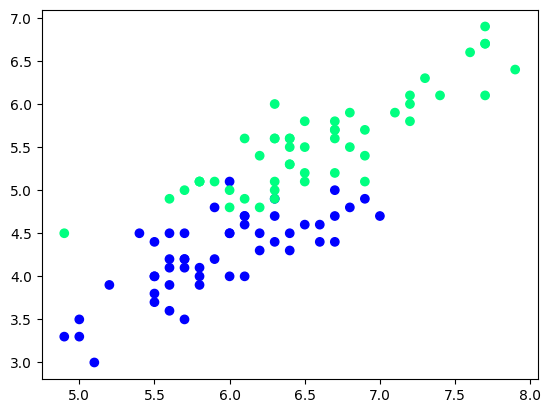

In [13]:
plt.scatter(df['sepal_length'],df['petal_length'],c=df['species'],cmap='winter')

In [14]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_length,petal_length,species
59,5.2,3.9,1
57,4.9,3.3,1
102,7.1,5.9,2
54,6.5,4.6,1
50,7.0,4.7,1
98,5.1,3.0,1
85,6.0,4.5,1
104,6.5,5.8,2
80,5.5,3.8,1
95,5.7,4.2,1


In [15]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [16]:
df_train

,sepal_length,petal_length,species
55,5.7,4.5,1
103,6.3,5.6,2
99,5.7,4.1,1
134,6.1,5.6,2
68,6.2,4.5,1
141,6.9,5.1,2
65,6.7,4.4,1
148,6.2,5.4,2
57,4.9,3.3,1
138,6.0,4.8,2


In [17]:
df_val

,sepal_length,petal_length,species
60,5.0,3.5,1
85,6.0,4.5,1
69,5.6,3.9,1
124,6.7,5.7,2
144,6.7,5.7,2


In [18]:
df_test

,sepal_length,petal_length,species
73,6.1,4.7,1
75,6.6,4.4,1
136,6.3,5.6,2
118,7.7,6.9,2
116,6.5,5.5,2


In [19]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [20]:
y_test

array([1, 1, 1, 2, 2])

# Case 1 - Bagging

In [21]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_length,petal_length,species
57,4.9,3.3,1
138,6.0,4.8,2
138,6.0,4.8,2
57,4.9,3.3,1
57,4.9,3.3,1
148,6.2,5.4,2
103,6.3,5.6,2
138,6.0,4.8,2


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [23]:
dt_bag1 = DecisionTreeClassifier()

In [27]:
def evaluate(model, X, y):
    """
    model : trained classifier
    X     : feature matrix (must have exactly 2 features)
    y     : target labels
    """
    # Accuracy
    score = model.score(X, y)
    print(score)

    # Plot decision regions
    plt.figure(figsize=(6, 4))
    plot_decision_regions(X.values if hasattr(X, "values") else X,
                          y.values if hasattr(y, "values") else y,
                          clf=model)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Regions")
    plt.show()

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


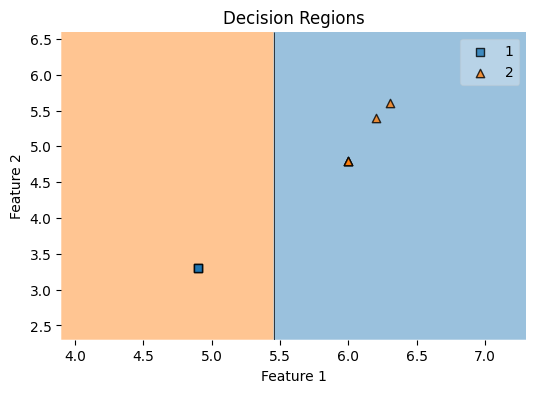

In [28]:
dt_bag1.fit(X, y)
evaluate(dt_bag1, X, y)


In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_length,petal_length,species
141,6.9,5.1,2
141,6.9,5.1,2
134,6.1,5.6,2
103,6.3,5.6,2
57,4.9,3.3,1
141,6.9,5.1,2
68,6.2,4.5,1
55,5.7,4.5,1


1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


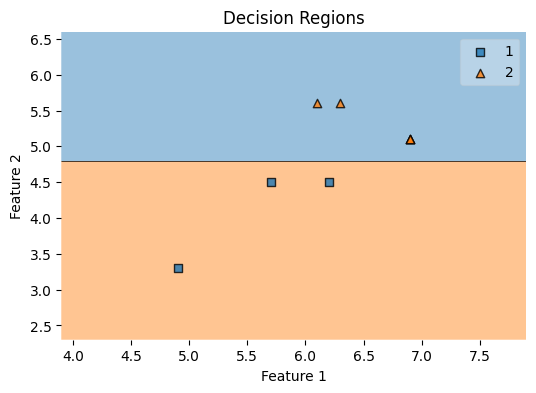

In [30]:
dt_bag2 = DecisionTreeClassifier()
dt_bag2.fit(X, y)
evaluate(dt_bag2,X,y)

In [31]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_length,petal_length,species
57,4.9,3.3,1
65,6.7,4.4,1
99,5.7,4.1,1
55,5.7,4.5,1
65,6.7,4.4,1
141,6.9,5.1,2
141,6.9,5.1,2
134,6.1,5.6,2


1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


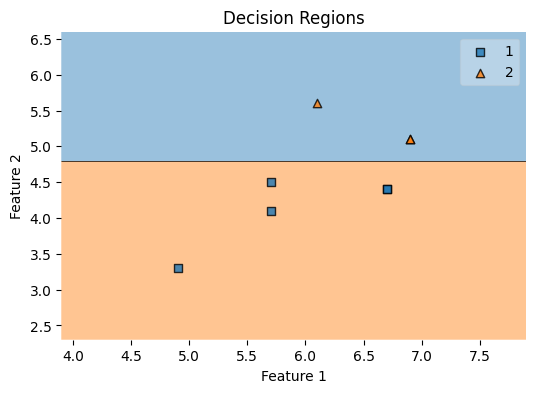

In [32]:
dt_bag3 = DecisionTreeClassifier()
dt_bag3.fit(X, y)
evaluate(dt_bag3,X,y)

## Predict

In [33]:
df_test

,sepal_length,petal_length,species
73,6.1,4.7,1
75,6.6,4.4,1
136,6.3,5.6,2
118,7.7,6.9,2
116,6.5,5.5,2


In [34]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [ ]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
131,3.8,6.4,2
137,3.1,5.5,2
130,2.8,6.1,2
145,3.0,5.2,2
52,3.1,4.9,1
96,2.9,4.2,1
75,3.0,4.4,1
100,3.3,6.0,2
53,2.3,4.0,1


In [ ]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
52,3.1,4.9,1
122,2.8,6.7,2
130,2.8,6.1,2
53,2.3,4.0,1
96,2.9,4.2,1
145,3.0,5.2,2
75,3.0,4.4,1


# Random Subspaces

In [ ]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

In [ ]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [ ]:
df1.sample(2,replace=True,axis=1)

,SepalWidthCm,Species
134,2.6,Iris-virginica
12,3.0,Iris-setosa
13,3.0,Iris-setosa
146,2.5,Iris-virginica
38,3.0,Iris-setosa
62,2.2,Iris-versicolor
77,3.0,Iris-versicolor
45,3.0,Iris-setosa
109,3.6,Iris-virginica
10,3.7,Iris-setosa


# Random Patches

In [ ]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Id
38,4.4,39
10,5.4,11
109,7.2,110
62,6.0,63
134,6.1,135
12,4.8,13
10,5.4,11
134,6.1,135
